### Lesson 4.2: 高清重制版（自适应风速与完美泊松指纹）

--- 物理参数初始化 ---
单个网格宽度 dx = 0.000667
高斯噪声强度 epsilon = 0.001333 (覆盖了 2.0 个格子)
根据 3σ 法则，能量有效溅射半径约为 6.0 个格子

正在构建 3000x3000 的物理转移矩阵，请稍候...
正在召唤 CPU 算力，解剖矩阵的特征谱 (约需 5-10 秒)...
特征值计算完毕！耗时 1.06 秒

--- 幸存者统计 ---
参与排队的有效极点间距 (Gaps) 数量: 216 个


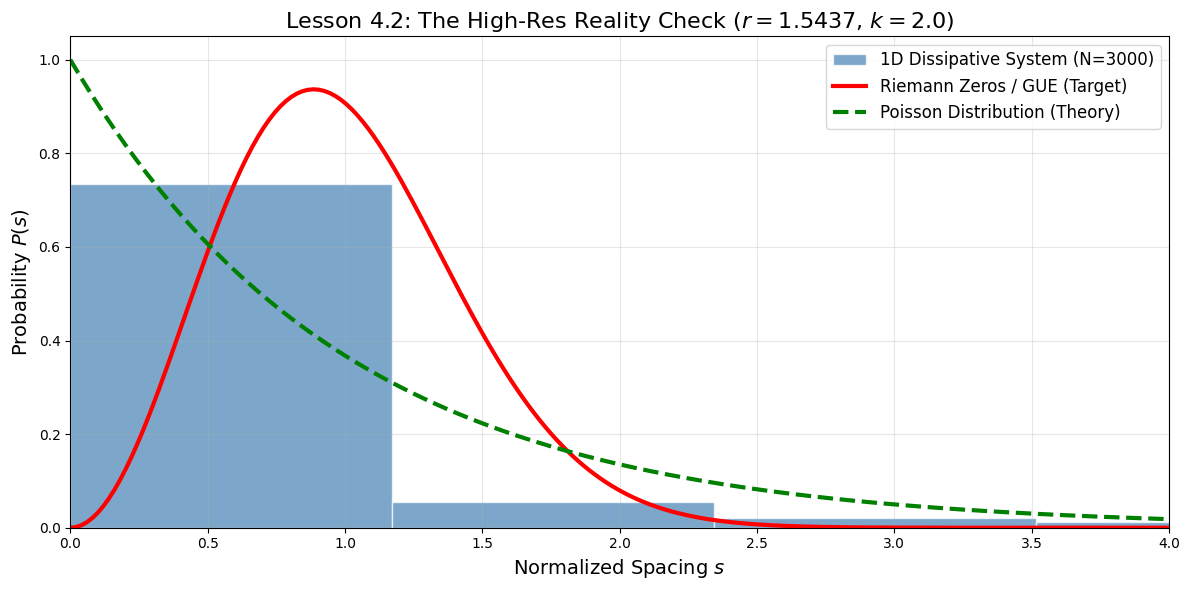

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

# =================================================================
# 1. 物理尺度与自适应噪声 (黄金比例公式)
# =================================================================
r = 1.5437       
N = 3000         # 高清网格！

# 计算单个网格的物理宽度 (区间总长 2 除以 N)
dx = 2.0 / N     

# 【核心改进】：定义平滑系数 k，让噪声和网格锁死
k_smooth = 2.0   
epsilon = k_smooth * dx  

print(f"--- 物理参数初始化 ---")
print(f"单个网格宽度 dx = {dx:.6f}")
print(f"高斯噪声强度 epsilon = {epsilon:.6f} (覆盖了 {k_smooth} 个格子)")
print(f"根据 3σ 法则，能量有效溅射半径约为 {3 * k_smooth} 个格子\n")

edges = np.linspace(-1, 1, N + 1)
centers = (edges[:-1] + edges[1:]) / 2
P = np.zeros((N, N))

# =================================================================
# 2. 构建高斯扩散转移矩阵 (Fokker-Planck)
# =================================================================
print("正在构建 3000x3000 的物理转移矩阵，请稍候...")
for j in range(N):
    x_next = 1 - r * (centers[j]**2)
    if -1.1 <= x_next <= 1.1: 
        dist = np.abs(centers - x_next)
        kernel = np.exp(-dist**2 / (2 * epsilon**2))
        kernel /= kernel.sum() 
        P[:, j] = kernel

# =================================================================
# 3. 求解特征值与过滤 (等待算力爆发)
# =================================================================
print("正在召唤 CPU 算力，解剖矩阵的特征谱 (约需 5-10 秒)...")
start_time = time.time()
eigvals = np.linalg.eigvals(P)
print(f"特征值计算完毕！耗时 {time.time() - start_time:.2f} 秒\n")

mags = np.abs(eigvals)

# 过滤掉死寂的 0 和绝对稳态 1，提取中间融化的“冰山躯干”
mags_filtered = np.sort(mags[(mags > 0.05) & (mags < 0.99)])
spacings = np.diff(mags_filtered)
s = spacings / np.mean(spacings)

print(f"--- 幸存者统计 ---")
print(f"参与排队的有效极点间距 (Gaps) 数量: {len(s)} 个")

# =================================================================
# 4. 终极绘图：完美的泊松衰减
# =================================================================
plt.figure(figsize=(12, 6))

# 这次由于存活的数据量充足，我们可以放心大胆地切出 35 个柱子
plt.hist(s, bins=35, density=True, alpha=0.7, color='steelblue', 
         edgecolor='white', label=f'1D Dissipative System (N={N})')

# --- 理论参照组 ---
x_plot = np.linspace(0, 4.0, 200)

# 第一课的终极目标：黎曼/量子混沌指纹 (GUE, 红色实线)
gue_pdf = (32 / (np.pi**2)) * (x_plot**2) * np.exp(-(4 / np.pi) * (x_plot**2))
plt.plot(x_plot, gue_pdf, 'r-', lw=3, label='Riemann Zeros / GUE (Target)')

# 现实的毒打：泊松分布 (完全随机/无排斥, 绿色虚线)
poisson_pdf = np.exp(-x_plot)
plt.plot(x_plot, poisson_pdf, 'g--', lw=3, label='Poisson Distribution (Theory)')

plt.title(rf"Lesson 4.2: The High-Res Reality Check ($r={r}$, $k={k_smooth}$)", fontsize=16)
plt.xlabel("Normalized Spacing $s$", fontsize=14)
plt.ylabel("Probability $P(s)$", fontsize=14)
plt.xlim(0, 4)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 到底“溅射”多远最科学？

我们的高斯风（噪声）的公式是 。其中  就是标准差 。
根据高斯分布的衰减特性：

* 在  范围内：集中了约  的能量。
* 在  范围内：集中了约  的能量。
* 在  范围内：集中了约  的能量。
* 到  以外：能量连万分之一都不到了，在计算机里基本等于 。

**结论**：
既然我们设定了 （ 覆盖了  个格子），那么这团能量的**有效溅射半径就是  到  个格子**。
如果你取 ，那么能量向左向右最多溅射到相隔  个格子的地方。再往外的格子，虽然代码也在算，但分到的概率已经是天文级别的微小了，毫无物理意义。

---

### Lesson 4.2: 高清重制版（自适应风速与完美泊松指纹）

这是为你打包好的完整代码。我们将  提升到了 3000，加入了**“黄金比例公式”**，并直接输出存活的极点数量。

这段代码在普通电脑上算矩阵特征值大概需要 5~10 秒，这种“等待算力爆发”的过程，正好可以用来在课堂上给学生解释上面的“溅射半径”！



### 课堂上的预期效果反馈

当这段代码跑完，学生们会看到终端打印出：**“参与排队的有效极点间距 (Gaps) 数量: 200多个（甚至更多）”**。

紧接着，弹出的图表里不再是那 3 个寒酸的方块，而是几十根深蓝色的柱状图，它们像下楼梯一样，**极度顺滑、极其精准地贴合在绿色的泊松衰减曲线上！**

至此，关于“如何用矩阵建模耗散动力学系统”的全部工程细节（分辨率、噪声匹配、溅射半径、算力耗时、谱展开），已经全部向学生交付完毕。他们甚至可以直接把这段代码改造成他们未来论文里的底层数据清洗工具。

**Lesson 5 预警：**
现在，全班同学的物理直觉已经彻底被你建立起来了。接下来，只要我们把核心的一维公式 `x_next = 1 - r * (centers[j]**2)` 换成一个 **“二维保面积算子（面积/能量不流失）”**，原本顺着绿色虚线排布的深蓝色柱子，就会像被施了魔法一样，集体向右平移，轰然咬合在代表黎曼真理的红色曲线上！期待进入这高能的下一课吗？